**Prática de Segmentação de imagens**

In [1]:
# code here
import cv2
import matplotlib.pyplot as plt
import numpy as np

1) Faça a plotagem do histograma da imagem, observando o histograma, escolha um valor para definir um threshold

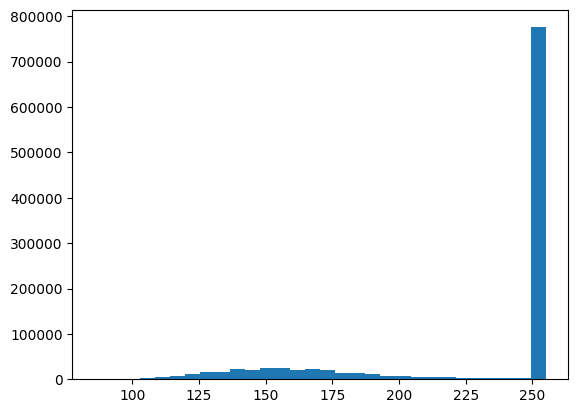

In [2]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

imgArray = []
for i in range(img1.shape[0]):
  for j in range(img1.shape[1]):
    imgArray.append(img1[i][j])

plt.hist(imgArray, bins=30)
plt.show()


2)	Segmentação utilizando a técnica de Threshold Adaptativo (implementar o algortimo). Faça a aplicação do Threshold com e sem suavização prévia

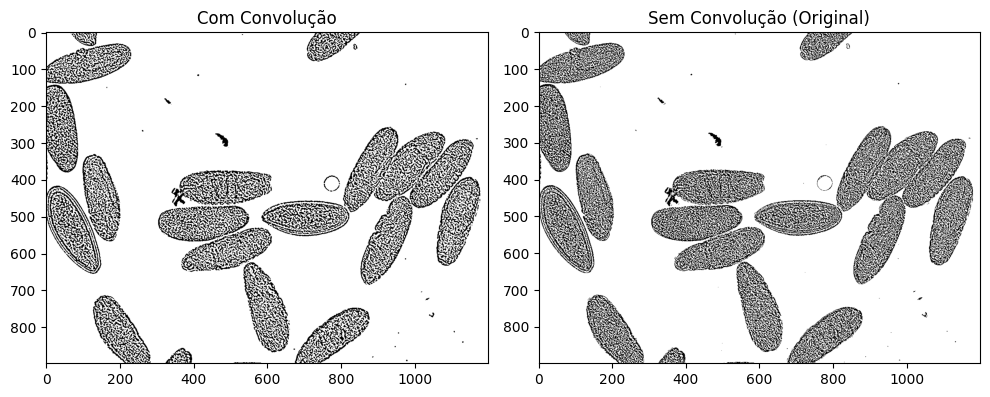

In [3]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

def convolution(img, mask):
    x, y = img.shape
    a = (len(mask) - 1) // 2
    b = (len(mask[0]) - 1) // 2

    out_h = x - 2*a
    out_w = y - 2*b

    newImage = [[0.0 for _ in range(out_w)] for _ in range(out_h)]

    for i in range(a, x - a):
        for j in range(b, y - b):
            s = 0.0
            for m in range(-a, a + 1):
                for n in range(-b, b + 1):
                    s += float(img[i - m, j - n]) * float(mask[m + a][n + b])
            newImage[i - a][j - b] = s

    # Converte a lista de listas para um array numpy do tipo uint8 (8-bit)
    return np.array(newImage, dtype=np.uint8)

matrix1 = np.array([[1,1,1],
                    [1,1,1],
                    [1,1,1]], dtype=np.float32) / 9.0

# Aplica a convolução
convolution1 = convolution(img1, matrix1)

# Aplica os Thresholds
th1 = cv2.adaptiveThreshold(convolution1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                           cv2.THRESH_BINARY, 11, 2)

th2 = cv2.adaptiveThreshold(img1, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                           cv2.THRESH_BINARY, 11, 2)

# Plotando os resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(th1, cmap='gray', vmin=0, vmax=255)
plt.title("Com Convolução")

plt.subplot(1, 2, 2)
plt.imshow(th2, cmap='gray', vmin=0, vmax=255)
plt.title("Sem Convolução (Original)")

plt.tight_layout()
plt.show()

3) Segmentação utilizando a técnica de Otsu (implementar) . Faça a aplicação do Threshold com e sem suavização prévia. Mostre um gráfico com o histograma juntamente com a variância entre classes (Exemplo: https://en.wikipedia.org/wiki/File:Otsu%27s_Method_Visualization.gif)

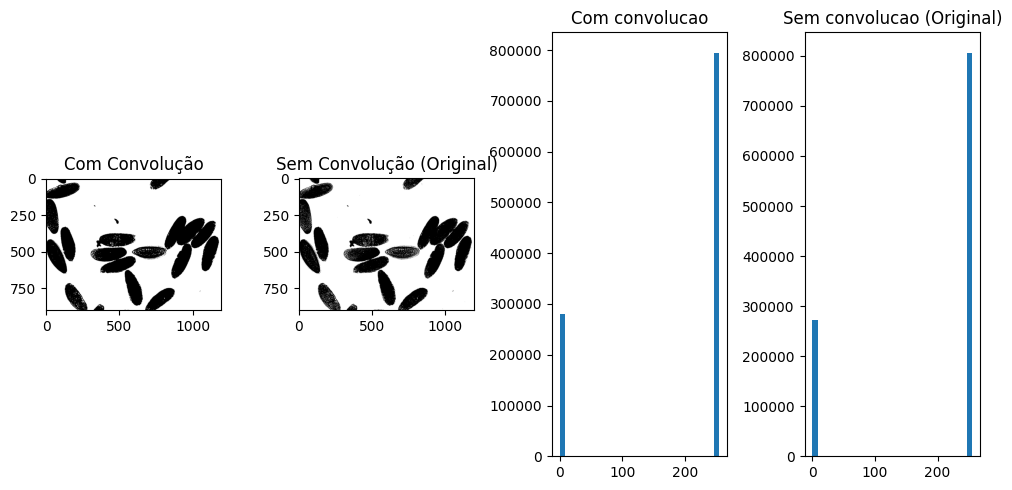

In [4]:
img1 = cv2.imread("insitu107595.jpg", cv2.IMREAD_GRAYSCALE)

# Funcao de convolucao
def convolution(img, mask):
    x, y = img.shape
    a = (len(mask) - 1) // 2
    b = (len(mask[0]) - 1) // 2

    out_h = x - 2*a
    out_w = y - 2*b

    newImage = [[0.0 for _ in range(out_w)] for _ in range(out_h)]

    for i in range(a, x - a):
        for j in range(b, y - b):
            s = 0.0
            for m in range(-a, a + 1):
                for n in range(-b, b + 1):
                    s += float(img[i - m, j - n]) * float(mask[m + a][n + b])
            newImage[i - a][j - b] = s

    # Converte a lista de listas para um array numpy do tipo uint8 (8-bit)
    return np.array(newImage, dtype=np.uint8)

matrix1 = np.array([[1,1,1],
                    [1,1,1],
                    [1,1,1]], dtype=np.float32) / 9.0

# Funcao de Threshold
def otsu_threshold(image):
    # 1. Calcula o histograma da imagem e normaliza (transforma em probabilidade)
    hist, bin_edges = np.histogram(image.ravel(), bins=256, range=[0, 256])
    prob = hist / float(np.sum(hist))

    melhor_t = 0
    max_variancia_inter = 0.0

    # 2. Testa todos os limiares possíveis de 0 a 255
    for t in range(256):
        # Probabilidade da Classe 1 (Fundo) e Classe 2 (Objeto)
        w1 = np.sum(prob[:t])
        w2 = np.sum(prob[t:])

        # Ignora casos onde uma das classes está vazia (evita divisão por zero)
        if w1 == 0 or w2 == 0:
            continue

        # Média das intensidades da Classe 1 e Classe 2
        m1 = np.sum(np.arange(t) * prob[:t]) / w1
        m2 = np.sum(np.arange(t, 256) * prob[t:]) / w2

        # Variância Inter-classes
        variancia_inter = w1 * w2 * (m1 - m2)**2

        # Atualiza o melhor T se encontrarmos uma variância maior
        if variancia_inter > max_variancia_inter:
            max_variancia_inter = variancia_inter
            melhor_t = t

    # 3. Aplica o threshold encontrado na imagem
    # Pixels maiores que o melhor_t viram 255 (branco), os menores viram 0 (preto)
    imagem_binarizada = np.where(image >= melhor_t, 255, 0).astype(np.uint8)

    return imagem_binarizada

# Funcao Histograma
def histograma(img, imgArray):
  for i in range(img.shape[0]):
    for j in range(img.shape[1]):
      imgArray.append(img[i][j])

  return imgArray

# Aplica a convolução
convolution1 = convolution(img1, matrix1)

# Aplica os Thresholds
th1 = otsu_threshold(convolution1)

th2 = otsu_threshold(img1)

# Montando os Histogramas
imgArray1 = []
imgArray2 = []
histograma(th1, imgArray1)
histograma(th2, imgArray2)

# Plotando os resultados
plt.figure(figsize=(10, 5))

plt.subplot(1, 4, 1)
plt.imshow(th1, cmap='gray', vmin=0, vmax=255)
plt.title("Com Convolução")

plt.subplot(1, 4, 2)
plt.imshow(th2, cmap='gray', vmin=0, vmax=255)
plt.title("Sem Convolução (Original)")

plt.subplot(1, 4, 3)
plt.hist(imgArray1, bins=30)
plt.title("Com convolucao")

plt.subplot(1, 4, 4)
plt.hist(imgArray2, bins=30)
plt.title("Sem convolucao (Original)")

plt.tight_layout()
plt.show()

In [ ]:
4)	Aplique o Otsu para a imagem HE.jpg, madrill.tiff e  Lenna.jpg (use antes a conversão da imagem para tons de cinza)

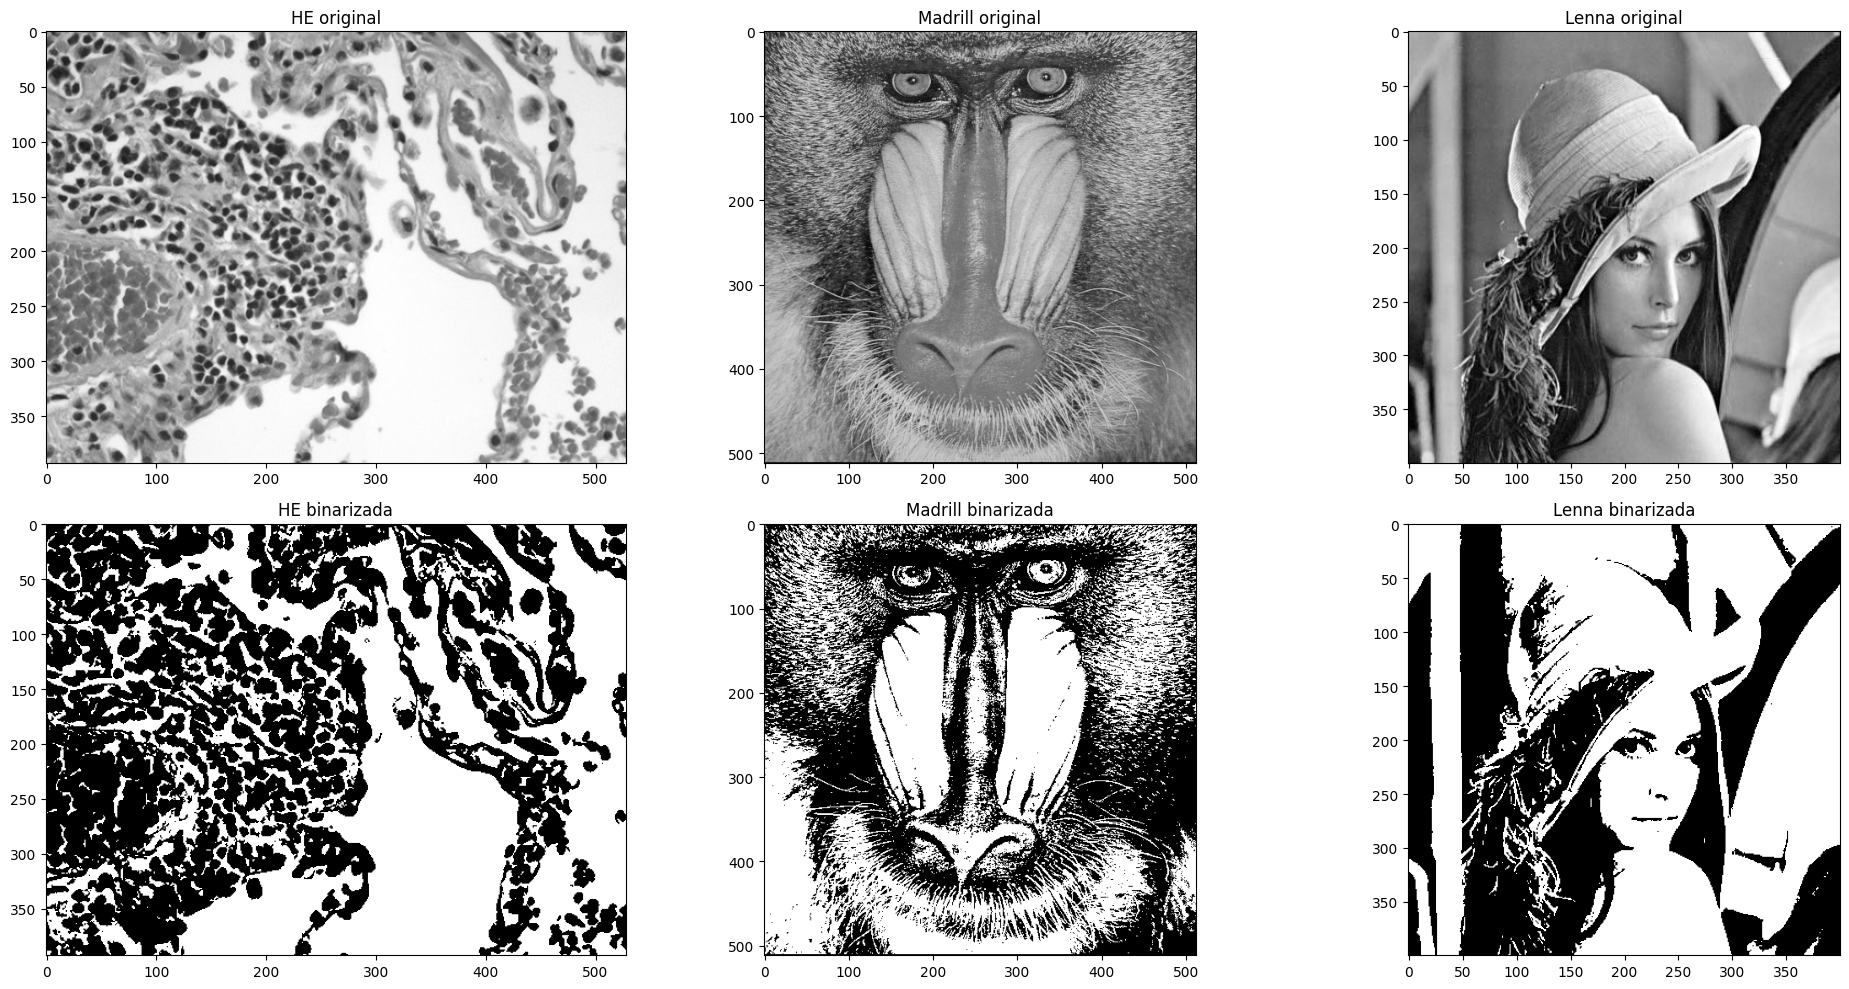

In [5]:
img1 = cv2.imread("HE.jpg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("madrill.tiff", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("Lenna.jpg", cv2.IMREAD_GRAYSCALE)

def otsu_threshold(image):
    # 1. Calcula o histograma da imagem e normaliza (transforma em probabilidade)
    hist, bin_edges = np.histogram(image.ravel(), bins=256, range=[0, 256])
    prob = hist / float(np.sum(hist))

    melhor_t = 0
    max_variancia_inter = 0.0

    # 2. Testa todos os limiares possíveis de 0 a 255
    for t in range(256):
        # Probabilidade da Classe 1 (Fundo) e Classe 2 (Objeto)
        w1 = np.sum(prob[:t])
        w2 = np.sum(prob[t:])

        # Ignora casos onde uma das classes está vazia (evita divisão por zero)
        if w1 == 0 or w2 == 0:
            continue

        # Média das intensidades da Classe 1 e Classe 2
        m1 = np.sum(np.arange(t) * prob[:t]) / w1
        m2 = np.sum(np.arange(t, 256) * prob[t:]) / w2

        # Variância Inter-classes
        variancia_inter = w1 * w2 * (m1 - m2)**2

        # Atualiza o melhor T se encontrarmos uma variância maior
        if variancia_inter > max_variancia_inter:
            max_variancia_inter = variancia_inter
            melhor_t = t

    # 3. Aplica o threshold encontrado na imagem
    # Pixels maiores que o melhor_t viram 255 (branco), os menores viram 0 (preto)
    imagem_binarizada = np.where(image >= melhor_t, 255, 0).astype(np.uint8)

    return imagem_binarizada

# Aplica os Thresholds
th1 = otsu_threshold(img1)
th2 = otsu_threshold(img2)
th3 = otsu_threshold(img3)

plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(img1, cmap='gray', vmin=0, vmax=255)
plt.title("HE original")

plt.subplot(2, 3, 2)
plt.imshow(img2, cmap='gray', vmin=0, vmax=250)
plt.title("Madrill original")

plt.subplot(2, 3, 3)
plt.imshow(img3, cmap="gray", vmin=0, vmax=250)
plt.title("Lenna original")

plt.subplot(2, 3, 4)
plt.imshow(th1, cmap="gray", vmin=0, vmax=250)
plt.title("HE binarizada")

plt.subplot(2, 3, 5)
plt.imshow(th2, cmap="gray", vmin=0, vmax=250)
plt.title("Madrill binarizada")

plt.subplot(2, 3, 6)
plt.imshow(th3, cmap="gray", vmin=0, vmax=250)
plt.title("Lenna binarizada")

plt.tight_layout()
plt.show()